# Working with FITS Files in Astronomy
This notebook explores how to open and visualize FITS (Flexible Image Transport System) files
using the `astropy` library. We'll also detect stars in the image and measure their brightness using aperture photometry.

The data used here is from the **Hubble Space Telescope (HST)**, observing the globular cluster **NGC 1261**.

In [10]:
from astropy.io import fits
import os
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
from astropy.io import fits
fits_file = fits.open('/content/drive/MyDrive/Astropy_data/jw02732-o001_t001_nircam_clear-f444w_i2d.fits.gz',memmap=True)

In [13]:
fits_file.info()

Filename: /content/drive/MyDrive/Astropy_data/jw02732-o001_t001_nircam_clear-f444w_i2d.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     279   ()      
  1  SCI           1 ImageHDU        75   (7090, 6056)   float32   
  2  ERR           1 ImageHDU        10   (7090, 6056)   float32   
  3  CON           1 ImageHDU        10   (7090, 6056, 2)   int32   
  4  WHT           1 ImageHDU         9   (7090, 6056)   float32   
  5  VAR_POISSON    1 ImageHDU         9   (7090, 6056)   float32   
  6  VAR_RNOISE    1 ImageHDU         9   (7090, 6056)   float32   
  7  VAR_FLAT      1 ImageHDU         9   (7090, 6056)   float32   
  8  HDRTAB        1 BinTableHDU    534   60R x 262C   [23A, 5A, 3A, 48A, 7A, 13A, 5A, 5A, 6A, 7A, 10A, 4A, L, D, D, 32A, 50A, 32A, 21A, 3A, 3A, 10A, 12A, 23A, 23A, 26A, 11A, 5A, 3A, 3A, 2A, 1A, 2A, 1A, L, 14A, 23A, 2A, 26A, 20A, 27A, 10A, K, L, L, L, L, 8A, 8A, 5A, D, D, D, D, D, D, 27A, D, D, 6A, 8A, 1A, 4A, 5A

In [14]:
data = fits_file[1].data
data

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype='>f4')

In [15]:
import numpy as np
np.shape(data)

(6056, 7090)

In [16]:
# Just check whether its all NAN
total = data.size
valid = np.sum(np.isfinite(data))
nan_count = np.sum(np.isnan(data))

print(f"Total pixels : {total:,}")
print(f"Valid pixels : {valid:,}")
print(f"NaN pixels   : {nan_count:,}")

Total pixels : 42,937,040
Valid pixels : 41,949,353
NaN pixels   : 987,687


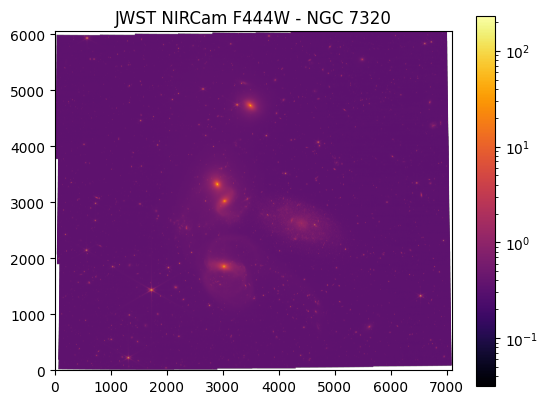

In [17]:
plt.figure()
plt.imshow(data, origin='lower', cmap='inferno', norm=LogNorm())
plt.colorbar()
plt.title('JWST NIRCam F444W - NGC 7320')
plt.show()

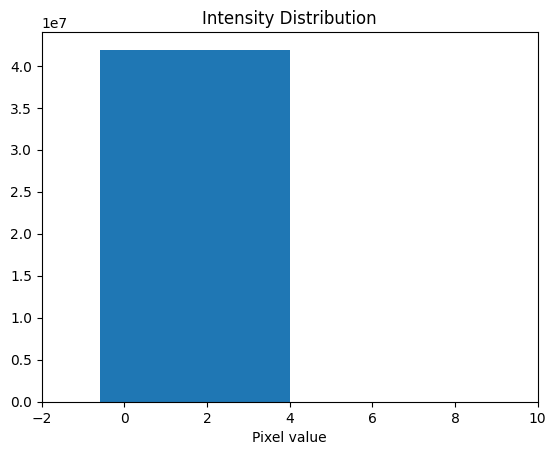

In [18]:
plt.figure()
plt.hist(np.ravel(data), bins = 50)
plt.title('Intensity Distribution')
plt.xlabel('Pixel value')
plt.xlim(-2, 10)
plt.show()

## Plot FITS Image in WCS coordinate

In [19]:
from astropy.wcs import WCS
wcs = WCS(fits_file[1].header)
wcs

Set DATE-AVG to '2022-06-11T21:44:40.692' from MJD-AVG.
Set DATE-END to '2022-06-12T02:21:27.738' from MJD-END'. [astropy.wcs.wcs]
Set DATE-AVG to '2022-06-11T21:44:40.692' from MJD-AVG.
Set DATE-END to '2022-06-12T02:21:27.738' from MJD-END'.
Set OBSGEO-B to   -34.308146 from OBSGEO-[XYZ].
Set OBSGEO-H to 1698567315.894 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -34.308146 from OBSGEO-[XYZ].
Set OBSGEO-H to 1698567315.894 from OBSGEO-[XYZ]'.


WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN'
CUNIT : 'deg' 'deg'
CRVAL : 338.99827612290323 33.9580905994201
CRPIX : 3543.970018348851 3025.873492572017
PC1_1 PC1_2  : 0.4709975515370747 -0.8821345172058969
PC2_1 PC2_2  : -0.8821345172058969 -0.4709975515370747
CDELT : 1.74765282596251e-05 1.74765282596251e-05
NAXIS : 7090  6056

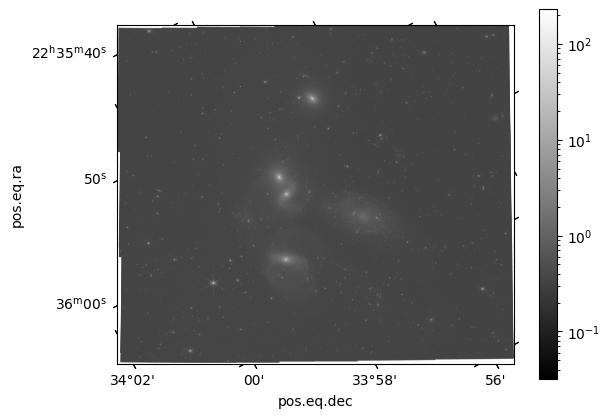

In [20]:
plt.figure()
plt.subplot(projection=wcs)
plt.imshow(data, origin='lower', cmap='gray', norm=LogNorm())
plt.colorbar()
plt.show()

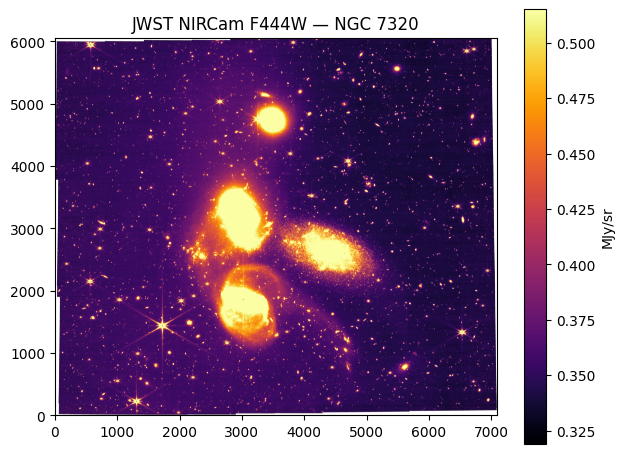

In [21]:
import matplotlib.pyplot as plt
from astropy.visualization import ZScaleInterval

zscale = ZScaleInterval()
vmin, vmax = zscale.get_limits(data[np.isfinite(data)])

plt.figure()
plt.imshow(data, origin='lower', cmap='inferno', vmin=vmin, vmax=vmax)
plt.colorbar(label='MJy/sr')
plt.title('JWST NIRCam F444W — NGC 7320')
plt.tight_layout()
plt.show()